**Instalar e importar librerías**

In [ ]:
!pip install -q ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

np.random.seed(42)

**Cargar el dataset de UCI**

In [ ]:
# Breast Cancer Wisconsin Diagnostic
# UCI Dataset ID = 17

breast_cancer = fetch_ucirepo(id=17)

X = breast_cancer.data.features
y = breast_cancer.data.targets

print("Dataset cargado")
print("Características:", X.shape)
print("Objetivo:", y.shape)

display(X.head())

Dataset cargado
Características: (569, 30)
Objetivo: (569, 1)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,...,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


**Explorar y preparar los datos**

In [ ]:
# Convertir la variable objetivo en una sola columna
y = y.iloc[:, 0]

# Convertir:
# B = 0
# M = 1

encoder = LabelEncoder()
y = encoder.fit_transform(y)

# División de datos
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

print("\nClases:")
print("0 =", encoder.inverse_transform([0])[0])
print("1 =", encoder.inverse_transform([1])[0])

Entrenamiento: (455, 30)
Prueba: (114, 30)

Clases:
0 = B
1 = M


# **Ciclo del algoritmo de enjambre**

**Representación de la partícula**

In [ ]:
# =====================================================
# REPRESENTACIÓN DE LA PARTÍCULA
# =====================================================

# Una partícula tiene la siguiente estructura:
#
# [n_estimators, max_depth, min_samples_split, min_samples_leaf]
#
# Ejemplo:
# [150, 15, 5, 2]

hiperparametros = [
    "n_estimators",
    "max_depth",
    "min_samples_split",
    "min_samples_leaf"
]

ejemplo_particula = np.array([
    150,
    15,
    5,
    2
])

print("REPRESENTACIÓN DE UNA PARTÍCULA")
print("=" * 45)

for nombre, valor in zip(
    hiperparametros,
    ejemplo_particula
):
    print(f"{nombre}: {valor}")

REPRESENTACIÓN DE UNA PARTÍCULA
n_estimators: 150
max_depth: 15
min_samples_split: 5
min_samples_leaf: 2


**Inicialización del enjambre**

In [ ]:
# =====================================================
# INICIALIZACIÓN DEL ENJAMBRE
# =====================================================

NUM_PARTICULAS = 15
ITERACIONES = 15

# Parámetros de PSO
w = 0.7
c1 = 1.5
c2 = 1.5

# Límites mínimos
limites_min = np.array([
    50,   # n_estimators
    3,    # max_depth
    2,    # min_samples_split
    1     # min_samples_leaf
], dtype=float)

# Límites máximos
limites_max = np.array([
    300,  # n_estimators
    30,   # max_depth
    15,   # min_samples_split
    8     # min_samples_leaf
], dtype=float)

# Crear posiciones aleatorias
posiciones = np.random.uniform(
    limites_min,
    limites_max,
    size=(NUM_PARTICULAS, 4)
)

# Velocidad inicial de cada partícula
velocidades = np.zeros(
    (NUM_PARTICULAS, 4)
)

print("ENJAMBRE INICIAL")
print("=" * 50)

print("Número de partículas:", NUM_PARTICULAS)

for i in range(5):
    print(
        f"Partícula {i+1}:",
        np.round(posiciones[i], 2)
    )

ENJAMBRE INICIAL
Número de partículas: 15
Partícula 1: [179.77  15.94   2.33   3.39]
Partícula 2: [145.05  13.77   9.54   4.74]
Partícula 3: [201.98  23.65  12.57   6.03]
Partícula 4: [288.88   3.49   4.55   1.05]
Partícula 5: [211.87  27.25   5.17   7.49]


**Función de aptitud**

In [ ]:
# =====================================================
# FUNCIÓN DE APTITUD - FITNESS
# =====================================================

cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)


def fitness(particula):

    # Convertir posición a hiperparámetros válidos
    n_estimators = int(round(particula[0]))
    max_depth = int(round(particula[1]))
    min_samples_split = int(round(particula[2]))
    min_samples_leaf = int(round(particula[3]))

    modelo = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42,
        n_jobs=-1
    )

    # Validación cruzada
    scores = cross_val_score(
        modelo,
        X_train,
        y_train,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    # Aptitud = Accuracy promedio
    return scores.mean()


# Ejemplo
aptitud_ejemplo = fitness(
    ejemplo_particula
)

print("FUNCIÓN DE APTITUD")
print("=" * 40)

print(
    "Partícula:",
    ejemplo_particula
)

print(
    "Fitness:",
    round(aptitud_ejemplo, 4)
)

FUNCIÓN DE APTITUD
Partícula: [150  15   5   2]
Fitness: 0.9561


**Preparar pBest y gBest**

In [ ]:
# =====================================================
# EVALUACIÓN INICIAL
# =====================================================

# Mejor posición personal de cada partícula
pbest_posiciones = posiciones.copy()

# Fitness inicial de cada partícula
pbest_scores = np.array([
    fitness(particula)
    for particula in posiciones
])

# Buscar la mejor partícula del enjambre
indice_mejor = np.argmax(
    pbest_scores
)

# Mejor posición global
gbest_posicion = (
    pbest_posiciones[indice_mejor].copy()
)

gbest_score = (
    pbest_scores[indice_mejor]
)

print("MEJOR SOLUCIÓN INICIAL")
print("=" * 45)

print(
    "gBest:",
    np.round(gbest_posicion, 2)
)

print(
    "Fitness gBest:",
    round(gbest_score, 4)
)

MEJOR SOLUCIÓN INICIAL
gBest: [254.8   26.87   4.97   2.48]
Fitness gBest: 0.9561


**Comportamiento de las partículas + Evolución**

In [ ]:
# =====================================================
# COMPORTAMIENTO Y EVOLUCIÓN DEL ENJAMBRE
# =====================================================

historial = []

for iteracion in range(ITERACIONES):

    print(
        f"\nITERACIÓN {iteracion + 1}"
    )

    print("-" * 50)

    for i in range(NUM_PARTICULAS):

        # Números aleatorios
        r1 = np.random.random(4)
        r2 = np.random.random(4)

        # ---------------------------------------------
        # 1. COMPORTAMIENTO DE LA PARTÍCULA
        # Actualización de velocidad
        # ---------------------------------------------

        velocidades[i] = (
            w * velocidades[i]
            +
            c1 * r1 *
            (
                pbest_posiciones[i]
                - posiciones[i]
            )
            +
            c2 * r2 *
            (
                gbest_posicion
                - posiciones[i]
            )
        )

        # ---------------------------------------------
        # 2. ACTUALIZAR POSICIÓN
        # ---------------------------------------------

        posiciones[i] = (
            posiciones[i]
            + velocidades[i]
        )

        # Mantener dentro de los límites
        posiciones[i] = np.clip(
            posiciones[i],
            limites_min,
            limites_max
        )

        # ---------------------------------------------
        # 3. EVALUAR NUEVA POSICIÓN
        # ---------------------------------------------

        score_actual = fitness(
            posiciones[i]
        )

        # ---------------------------------------------
        # 4. ACTUALIZAR pBest
        # ---------------------------------------------

        if score_actual > pbest_scores[i]:

            pbest_scores[i] = score_actual

            pbest_posiciones[i] = (
                posiciones[i].copy()
            )

        # ---------------------------------------------
        # 5. ACTUALIZAR gBest
        # ---------------------------------------------

        if score_actual > gbest_score:

            gbest_score = score_actual

            gbest_posicion = (
                posiciones[i].copy()
            )

    # Guardar evolución
    historial.append(
        gbest_score
    )

    print(
        f"Mejor Accuracy: "
        f"{gbest_score:.4f}"
    )


ITERACIÓN 1
--------------------------------------------------
Mejor Accuracy: 0.9561

ITERACIÓN 2
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 3
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 4
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 5
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 6
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 7
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 8
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 9
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 10
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 11
--------------------------------------------------
Mejor Accuracy: 0.9582

ITERACIÓN 12
---------------------------

**Finalización del Algortimo**

PSO FINALIZADO
Criterio de parada: 15 iteraciones

MEJOR SOLUCIÓN ENCONTRADA
n_estimators: 300
max_depth: 27
min_samples_split: 6
min_samples_leaf: 1

Mejor fitness: 0.9582


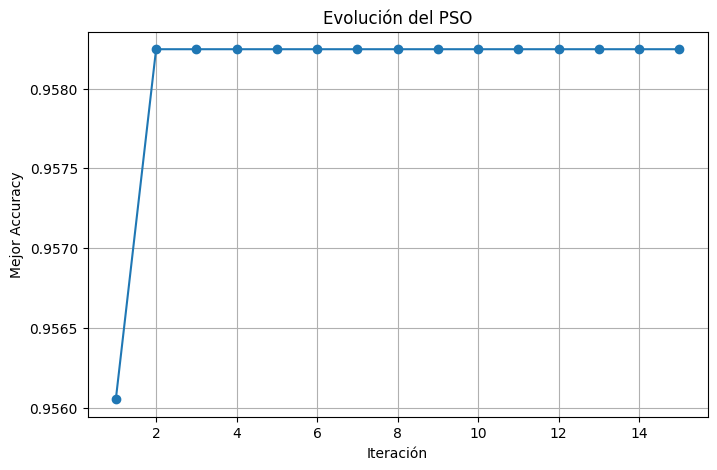

In [ ]:
# =====================================================
# FINALIZACIÓN DEL ALGORITMO
# =====================================================

# Convertir gBest a hiperparámetros enteros

mejor_n_estimators = int(
    round(gbest_posicion[0])
)

mejor_max_depth = int(
    round(gbest_posicion[1])
)

mejor_min_samples_split = int(
    round(gbest_posicion[2])
)

mejor_min_samples_leaf = int(
    round(gbest_posicion[3])
)


print("=" * 55)
print("PSO FINALIZADO")
print("=" * 55)

print(
    "Criterio de parada:",
    ITERACIONES,
    "iteraciones"
)

print("\nMEJOR SOLUCIÓN ENCONTRADA")

print(
    "n_estimators:",
    mejor_n_estimators
)

print(
    "max_depth:",
    mejor_max_depth
)

print(
    "min_samples_split:",
    mejor_min_samples_split
)

print(
    "min_samples_leaf:",
    mejor_min_samples_leaf
)

print(
    "\nMejor fitness:",
    round(gbest_score, 4)
)


# Gráfico de evolución

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, ITERACIONES + 1),
    historial,
    marker="o"
)

plt.xlabel("Iteración")
plt.ylabel("Mejor Accuracy")
plt.title("Evolución del PSO")

plt.grid()

plt.show()

In [ ]:
# =====================================================
# MODELO BASE
# =====================================================

modelo_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1
)

modelo_base.fit(
    X_train,
    y_train
)

pred_base = modelo_base.predict(
    X_test
)


# =====================================================
# MODELO OPTIMIZADO CON PSO
# =====================================================

modelo_pso = RandomForestClassifier(
    n_estimators=mejor_n_estimators,
    max_depth=mejor_max_depth,
    min_samples_split=mejor_min_samples_split,
    min_samples_leaf=mejor_min_samples_leaf,
    random_state=42,
    n_jobs=-1
)

modelo_pso.fit(
    X_train,
    y_train
)

pred_pso = modelo_pso.predict(
    X_test
)


# =====================================================
# MÉTRICAS
# =====================================================

resultados = pd.DataFrame({

    "Métrica": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score"
    ],

    "Random Forest Base": [
        accuracy_score(y_test, pred_base),
        precision_score(y_test, pred_base),
        recall_score(y_test, pred_base),
        f1_score(y_test, pred_base)
    ],

    "Random Forest + PSO": [
        accuracy_score(y_test, pred_pso),
        precision_score(y_test, pred_pso),
        recall_score(y_test, pred_pso),
        f1_score(y_test, pred_pso)
    ]
})


print("=" * 60)
print("RESULTADOS FINALES")
print("=" * 60)

display(
    resultados.style.format({
        "Random Forest Base": "{:.4f}",
        "Random Forest + PSO": "{:.4f}"
    })
)


print("\nMatriz de confusión PSO:")

print(
    confusion_matrix(
        y_test,
        pred_pso
    )
)

RESULTADOS FINALES


,Métrica,Random Forest Base,Random Forest + PSO
0,Accuracy,0.9737,0.9737
1,Precision,1.0000,1.0000
2,Recall,0.9286,0.9286
3,F1-score,0.9630,0.9630



Matriz de confusión PSO:
[[72  0]
 [ 3 39]]
